## Setup: Install & Import Dependencies

In [1]:
import os
import json
import re
import random
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks
from tensorflow.keras.preprocessing.image import ImageDataGenerator

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


## Global Configuration

In [2]:

IMG_SIZE     = (256, 256)      
IMG_CHANNELS = 3               
INPUT_SHAPE  = IMG_SIZE + (IMG_CHANNELS,)


CLASS_NAMES = ['Brown_Rust', 'Healthy', 'Yellow_Rust']
NUM_CLASSES = len(CLASS_NAMES)


BATCH_SIZE    = 32      
EPOCHS        = 50     
LEARNING_RATE = 1e-4    



TRAIN_SPLIT = 0.70      
VAL_SPLIT   = 0.30


KAGGLE_INPUT = '/kaggle/input/behzad-safari-jalal/data'

if os.path.isdir(KAGGLE_INPUT):
    DATA_DIR = KAGGLE_INPUT
else:
    import kagglehub
    DATA_DIR = os.path.join(kagglehub.dataset_download('sinadunk23/behzad-safari-jalal'),
                            'data')

SPLIT_ROOT = '/kaggle/working/data_70_30' if os.path.isdir('/kaggle/working') else 'data_70_30'
TRAIN_DIR  = os.path.join(SPLIT_ROOT, 'train')
VAL_DIR    = os.path.join(SPLIT_ROOT, 'val')
MODEL_PATH = 'wheat_disease_cnn.keras'


def class_sources(class_name):
    """Every folder under DATA_DIR holding images of this class.

    The dataset ships pre-split, so a class lives in two folders (train/ and val/).
    Matching ignores case and the space/underscore difference, so 'Brown_Rust'
    finds 'Brown_rust' and 'Brown rust' alike.
    """
    wanted = class_name.lower().replace('_', ' ')
    found = sorted(os.path.join(parent, d)
                   for parent, dirs, _ in os.walk(DATA_DIR)
                   for d in dirs
                   if d.lower().replace('_', ' ') == wanted)
    assert found, f'No folder for class {class_name} under {DATA_DIR}'
    return found


CLASS_SOURCES = {name: class_sources(name) for name in CLASS_NAMES}

print('Classes    :', CLASS_NAMES)
print('Data dir   :', DATA_DIR)
for name, folders in CLASS_SOURCES.items():
    print(f'  {name:12s}', [os.path.relpath(f, DATA_DIR) for f in folders])
print('Split root :', SPLIT_ROOT)


Classes    : ['Brown_Rust', 'Healthy', 'Yellow_Rust']
Data dir   : /kaggle/input/datasets/sinadunk23/behzad-safari-jalal/data
  Brown_Rust   ['train/Brown_rust', 'val/Brown_rust']
  Healthy      ['train/Healthy', 'val/Healthy']
  Yellow_Rust  ['train/Yellow_rust', 'val/Yellow_rust']
Split root : /kaggle/working/data_70_30


In [3]:
# Data Acquisition and Splitting

In [4]:
import hashlib
import shutil


IMG_EXTS = ('.jpg', '.jpeg', '.jfif', '.png', '.bmp', '.gif')

def list_images(directory):
    """Full paths of the image files directly inside `directory`."""
    if not os.path.isdir(directory):
        return []
    return [os.path.join(directory, f) for f in sorted(os.listdir(directory))
            if f.lower().endswith(IMG_EXTS)]


def file_md5(path):
    """Hash of the raw file bytes, used to spot byte-identical duplicates."""
    with open(path, 'rb') as fh:
        return hashlib.md5(fh.read()).hexdigest()


def link_or_copy(src, dst):
    """Place `src` at `dst` without duplicating the image data.
    A hard link costs no disk space; copying is the fallback when the
    filesystem refuses (for example across drives)."""
    try:
        os.link(src, dst)
    except OSError:
        shutil.copy2(src, dst)


def print_split_table(rows):
    """rows = [(class name, n_train, n_val), ...]. Returns the total image count."""
    print(f"{'Class':14s}{'train':>8s}{'val':>8s}{'total':>8s}{'val %':>8s}")
    print('-' * 46)
    tr_tot = va_tot = 0
    for name, tr, va in rows:
        tr_tot += tr
        va_tot += va
        print(f"{name:14s}{tr:8d}{va:8d}{tr + va:8d}{100 * va / max(1, tr + va):7.1f}%")
    print('-' * 46)
    total = tr_tot + va_tot
    print(f"{'TOTAL':14s}{tr_tot:8d}{va_tot:8d}{total:8d}"
          f"{100 * va_tot / max(1, total):7.1f}%")
    return total

print(f"{'Class':14s}{'images':>9s}")
print('-' * 23)
total_images = 0
for name in CLASS_NAMES:
    n = sum(len(list_images(folder)) for folder in CLASS_SOURCES[name])
    assert n > 0, f'No images found for {name}'
    total_images += n
    print(f'{name:14s}{n:9d}')
print('-' * 23)
print(f"{'TOTAL':14s}{total_images:9d}")



Class            images
-----------------------
Brown_Rust         1128
Healthy            1395
Yellow_Rust        1156
-----------------------
TOTAL              3679


In [5]:

from collections import defaultdict

rng = np.random.RandomState(SEED)
rows = []
print(f'Splitting {TRAIN_SPLIT:.0%}:{VAL_SPLIT:.0%} -> {SPLIT_ROOT}\n')

for name in CLASS_NAMES:
    pool = [path for folder in CLASS_SOURCES[name] for path in list_images(folder)]

    groups = defaultdict(list)
    for path in pool:
        groups[file_md5(path)].append(path)
    keys = sorted(groups)
    rng.shuffle(keys)

    quota = int(round(TRAIN_SPLIT * len(pool)))
    assigned, side = 0, {}
    for key in keys:
        side[key] = 'train' if assigned < quota else 'val'
        assigned += len(groups[key])

    counts = {'train': 0, 'val': 0}
    for key in keys:
        target_dir = os.path.join(SPLIT_ROOT, side[key], name)
        os.makedirs(target_dir, exist_ok=True)
        for path in groups[key]:
          
            filename = os.path.basename(path)
            if filename.lower().endswith('.jfif'):
                filename = filename[:-len('.jfif')] + '.jpg'
            dst = os.path.join(target_dir, filename)
            if not os.path.exists(dst):
                link_or_copy(path, dst)
            counts[side[key]] += 1
    rows.append((name, counts['train'], counts['val']))

print_split_table(rows)
print(f'\nTrain dir: {TRAIN_DIR}')
print(f'Val dir  : {VAL_DIR}')


Splitting 70%:30% -> /kaggle/working/data_70_30

Class            train     val   total   val %
----------------------------------------------
Brown_Rust         790     338    1128   30.0%
Healthy            976     419    1395   30.0%
Yellow_Rust        809     347    1156   30.0%
----------------------------------------------
TOTAL             2575    1104    3679   30.0%

Train dir: /kaggle/working/data_70_30/train
Val dir  : /kaggle/working/data_70_30/val


In [6]:
# Data Preprocessing

In [7]:

datagen = ImageDataGenerator(rescale=1.0 / 255)


train_gen = datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    color_mode='rgb',
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    classes=CLASS_NAMES,
    shuffle=True,
    seed=SEED,
)

val_gen = datagen.flow_from_directory(
    VAL_DIR,
    target_size=IMG_SIZE,
    color_mode='rgb',
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    classes=CLASS_NAMES,
    shuffle=False,  
)


_tr = [k.lower() for k in train_gen.class_indices]
_va = [k.lower() for k in val_gen.class_indices]
assert _tr == _va, f"train/val class order differs: {_tr} vs {_va}"

print("\nTrain class_indices:", train_gen.class_indices)
print("Val   class_indices:", val_gen.class_indices)
print("Index -> label     :", dict(enumerate(CLASS_NAMES)))
print(f"\ntrain: {train_gen.samples} images  |  val: {val_gen.samples} images  "
      f"({100 * val_gen.samples / (train_gen.samples + val_gen.samples):.1f}% val)")


Found 2575 images belonging to 3 classes.
Found 1104 images belonging to 3 classes.

Train class_indices: {'Brown_Rust': 0, 'Healthy': 1, 'Yellow_Rust': 2}
Val   class_indices: {'Brown_Rust': 0, 'Healthy': 1, 'Yellow_Rust': 2}
Index -> label     : {0: 'Brown_Rust', 1: 'Healthy', 2: 'Yellow_Rust'}

train: 2575 images  |  val: 1104 images  (30.0% val)


In [8]:
# Data integrity check — train/val leakage

In [9]:

from collections import defaultdict


def hash_split(split_dir, class_dirs):
    """md5(file bytes) -> ['<class folder>/<file name>', ...]."""
    hashes = defaultdict(list)
    for folder in class_dirs:
        for path in list_images(os.path.join(split_dir, folder)):
            hashes[file_md5(path)].append(f'{folder}/{os.path.basename(path)}')
    return hashes


train_h = hash_split(TRAIN_DIR, CLASS_NAMES)
val_h   = hash_split(VAL_DIR,   CLASS_NAMES)

n_train = sum(len(v) for v in train_h.values())
n_val   = sum(len(v) for v in val_h.values())
dup_train = sum(len(v) - 1 for v in train_h.values() if len(v) > 1)
dup_val   = sum(len(v) - 1 for v in val_h.values()   if len(v) > 1)

overlap  = set(train_h) & set(val_h)
n_leaked = sum(len(val_h[k]) for k in overlap)

print(f"train images            : {n_train} ({len(train_h)} unique)")
print(f"val   images            : {n_val} ({len(val_h)} unique)")
print(f"duplicates within train : {dup_train}")
print(f"duplicates within val   : {dup_val}")
print(f"\nEXACT train/val overlap : {len(overlap)} distinct images "
      f"-> {n_leaked} val images ({100 * n_leaked / max(1, n_val):.2f}% of val)")

if overlap:
    print("\n!! LEAKAGE DETECTED - validation accuracy will be inflated.")
    print("   Examples (same bytes on both sides):")
    for k in list(overlap)[:10]:
        print(f"     train:{train_h[k][0]}   ==   val:{val_h[k][0]}")
    print("\n   -> Treat the headline accuracy as optimistic, and/or de-duplicate")
    print("      before reporting. LEAKED_VAL_FILES below lists every affected file.")
    LEAKED_VAL_FILES = sorted(f for k in overlap for f in val_h[k])
else:
    LEAKED_VAL_FILES = []
    print("\nNo byte-identical images shared between train and val.")
    print("Split is clean at the exact-duplicate level.")
   


train images            : 2575 (2575 unique)
val   images            : 1104 (1104 unique)
duplicates within train : 0
duplicates within val   : 0

EXACT train/val overlap : 0 distinct images -> 0 val images (0.00% of val)

No byte-identical images shared between train and val.
Split is clean at the exact-duplicate level.


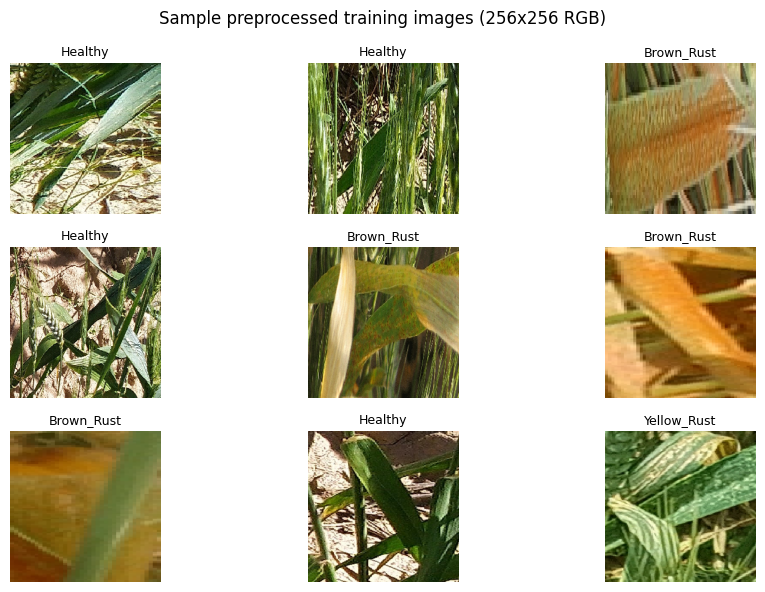

In [10]:
images, labels = next(train_gen)
plt.figure(figsize=(10, 6))
for i in range(min(9, len(images))):
    plt.subplot(3, 3, i + 1)
    plt.imshow(images[i])
    plt.title(CLASS_NAMES[np.argmax(labels[i])], fontsize=9)
    plt.axis('off')
plt.suptitle('Sample preprocessed training images (256x256 RGB)')
plt.tight_layout()
plt.show()


train_gen.reset()

In [11]:
# CNN Architecture Design

In [12]:
def build_cnn(input_shape=INPUT_SHAPE, num_classes=NUM_CLASSES):
    """Custom CNN: 6 x (Conv3x3 + ReLU + MaxPool) -> Dense -> SoftMax.

    Matches the paper's Section 3.2 architecture exactly. There is no dropout,
    because the paper's architecture does not have any.
    """
    model = models.Sequential(name='WheatLeafCNN')
    model.add(layers.Input(shape=input_shape))

    filters = [32, 64, 128, 128, 256, 256]  # 6 conv layers
    for i, f in enumerate(filters, start=1):
        
        model.add(layers.Conv2D(f, (3, 3), strides=(1, 1), activation='relu',
                                padding='same', name=f'conv{i}'))
        model.add(layers.MaxPooling2D((2, 2), name=f'pool{i}'))  # 6 max-pool layers

    # Fully connected head: one FC layer, then the SoftMax classifier
    model.add(layers.Flatten(name='flatten'))
    model.add(layers.Dense(256, activation='relu', name='dense'))
    model.add(layers.Dense(num_classes, activation='softmax', name='output'))
    return model

model = build_cnn()
model.summary()


I0000 00:00:1784787458.787742      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1784787458.791240      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "WheatLeafCNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 256, 256, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 128, 128, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv2D)                  │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool3 (MaxPooling2D)            │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv4 (Conv2D)                  │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool4 (MaxPooling2D)            │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv5 (Conv2D)                  │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool5 (MaxPooling2D)            │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv6 (Conv2D)                  │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool6 (MaxPooling2D)            │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,048,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,175,683 (8.30 MB)

 Trainable params: 2,175,683 (8.30 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
# validation — confirm the architecture is identical

In [14]:

conv_layers  = [l for l in model.layers if isinstance(l, layers.Conv2D)]
pool_layers  = [l for l in model.layers if isinstance(l, layers.MaxPooling2D)]
dense_layers = [l for l in model.layers if isinstance(l, layers.Dense)]


assert len(conv_layers) == 6, f'Expected 6 Conv2D layers, found {len(conv_layers)}'


for l in conv_layers:
    assert tuple(l.kernel_size) == (3, 3), f'{l.name}: kernel {l.kernel_size} != (3, 3)'
    assert l.activation.__name__ == 'relu', f'{l.name}: activation {l.activation.__name__} != relu'


assert len(pool_layers) == 6, f'Expected 6 MaxPooling2D layers, found {len(pool_layers)}'


feature_extractor = [l for l in model.layers if isinstance(l, (layers.Conv2D, layers.MaxPooling2D))]
expected_pattern = ['Conv2D', 'MaxPooling2D'] * 6
actual_pattern = [type(l).__name__ for l in feature_extractor]
assert actual_pattern == expected_pattern, 'Conv/Pool layers do not alternate as Conv->Pool x6'


assert len(dense_layers) >= 2, 'Expected a hidden Dense layer plus the output Dense layer'
hidden_dense = dense_layers[-2]
assert hidden_dense.activation.__name__ == 'relu', 'Hidden Dense layer should use ReLU'


output_layer = dense_layers[-1]
assert output_layer.units == NUM_CLASSES, f'Output units {output_layer.units} != NUM_CLASSES {NUM_CLASSES}'
assert output_layer.activation.__name__ == 'softmax', 'Output layer must use SoftMax'

print('Architecture matches doc.md Step 3 exactly:')
print(f'  Conv2D layers (3x3, ReLU) : {len(conv_layers)}')
print(f'  MaxPooling2D layers       : {len(pool_layers)}')
print(f'  Conv->Pool alternation    : OK')
print(f'  Hidden Dense layer        : {hidden_dense.name} ({hidden_dense.units} units, ReLU)')
print(f'  Output layer              : {output_layer.name} ({output_layer.units} units, SoftMax)')

print('\nSpatial dimension after each pooling stage:')
size = IMG_SIZE[0]
for i in range(1, 7):
    size //= 2
    print(f'  after pool{i}: {size} x {size}')
print('  -> 4x4 feature map is flattened and fed to the Dense layer')

Architecture matches doc.md Step 3 exactly:
  Conv2D layers (3x3, ReLU) : 6
  MaxPooling2D layers       : 6
  Conv->Pool alternation    : OK
  Hidden Dense layer        : dense (256 units, ReLU)
  Output layer              : output (3 units, SoftMax)

Spatial dimension after each pooling stage:
  after pool1: 128 x 128
  after pool2: 64 x 64
  after pool3: 32 x 32
  after pool4: 16 x 16
  after pool5: 8 x 8
  after pool6: 4 x 4
  -> 4x4 feature map is flattened and fed to the Dense layer


In [15]:
# Model Training

In [16]:
model.compile(
    optimizer=optimizers.Adam(learning_rate=LEARNING_RATE),
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)

cb = [callbacks.ModelCheckpoint(MODEL_PATH, monitor='val_accuracy', mode='max',
                                save_best_only=True, verbose=0)]

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    callbacks=cb,
)

FINAL_MODEL_PATH = 'wheat_disease_cnn_final_epoch.keras'
model.save(FINAL_MODEL_PATH)

_ran  = len(history.history['val_accuracy'])
_best = int(np.argmax(history.history['val_accuracy']))
print(f"\nEpochs run              : {_ran} / {EPOCHS}"
      f"{'  (FULL - paper protocol)' if _ran == EPOCHS else '  (STOPPED EARLY)'}")
print(f"Final-epoch val_accuracy: {history.history['val_accuracy'][-1]:.4f}   <- paper protocol")
print(f"Best-epoch val_accuracy : {history.history['val_accuracy'][_best]:.4f} (epoch {_best + 1})")
print(f"Final-epoch train acc   : {history.history['accuracy'][-1]:.4f}")
print(f"Generalization gap      : "
      f"{history.history['accuracy'][-1] - history.history['val_accuracy'][-1]:+.4f}")


Epoch 1/50


2026-07-23 06:17:48.167344: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-23 06:17:48.337542: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


 1/81 ━━━━━━━━━━━━━━━━━━━━ 16:22 12s/step - accuracy: 0.5000 - loss: 1.0966

I0000 00:00:1784787473.467525     148 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


54/81 ━━━━━━━━━━━━━━━━━━━━ 3s 144ms/step - accuracy: 0.4351 - loss: 0.9611

2026-07-23 06:18:03.124531: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-23 06:18:03.288549: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


81/81 ━━━━━━━━━━━━━━━━━━━━ 37s 312ms/step - accuracy: 0.6334 - loss: 0.7122 - val_accuracy: 0.8053 - val_loss: 0.4365
Epoch 2/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 16s 197ms/step - accuracy: 0.8885 - loss: 0.2878 - val_accuracy: 0.8877 - val_loss: 0.3234
Epoch 3/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 16s 196ms/step - accuracy: 0.9305 - loss: 0.1874 - val_accuracy: 0.9339 - val_loss: 0.1762
Epoch 4/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 16s 196ms/step - accuracy: 0.9460 - loss: 0.1513 - val_accuracy: 0.9357 - val_loss: 0.1901
Epoch 5/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 16s 198ms/step - accuracy: 0.9639 - loss: 0.1107 - val_accuracy: 0.9665 - val_loss: 0.0961
Epoch 6/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 16s 193ms/step - accuracy: 0.9592 - loss: 0.1168 - val_accuracy: 0.9656 - val_loss: 0.1097
Epoch 7/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 16s 192ms/step - accuracy: 0.9744 - loss: 0.0798 - val_accuracy: 0.9592 - val_loss: 0.0930
Epoch 8/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 16s 193ms/step - accuracy: 0.9658 - loss: 0.1031 - val_accuracy: 0.950

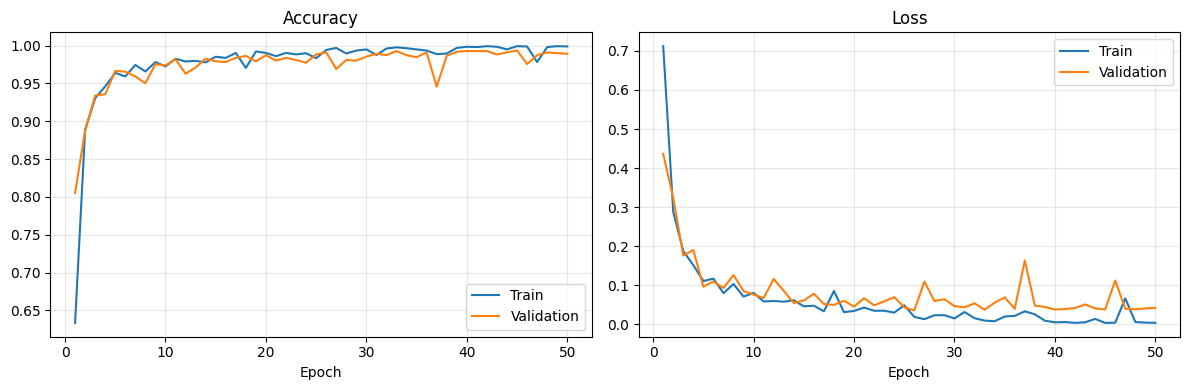

In [17]:
# Plot training curves
def plot_history(h):
    acc, val_acc = h.history['accuracy'], h.history['val_accuracy']
    loss, val_loss = h.history['loss'], h.history['val_loss']
    epochs_range = range(1, len(acc) + 1)

    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Train')
    plt.plot(epochs_range, val_acc, label='Validation')
    plt.title('Accuracy'); plt.xlabel('Epoch'); plt.legend(); plt.grid(alpha=0.3)

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Train')
    plt.plot(epochs_range, val_loss, label='Validation')
    plt.title('Loss'); plt.xlabel('Epoch'); plt.legend(); plt.grid(alpha=0.3)
    plt.tight_layout(); plt.show()

plot_history(history)

In [18]:
# Evaluation

Model                          val acc   val loss
-------------------------------------------------
final epoch                     0.9891     0.0417
best checkpoint                 0.9891     0.0417
-------------------------------------------------

Headline: final-epoch model, val accuracy 0.9891

35/35 ━━━━━━━━━━━━━━━━━━━━ 6s 141ms/step
              precision    recall  f1-score   support

  Brown_Rust      0.994     0.982     0.988       338
     Healthy      0.990     0.993     0.992       419
 Yellow_Rust      0.983     0.991     0.987       347

    accuracy                          0.989      1104
   macro avg      0.989     0.989     0.989      1104
weighted avg      0.989     0.989     0.989      1104



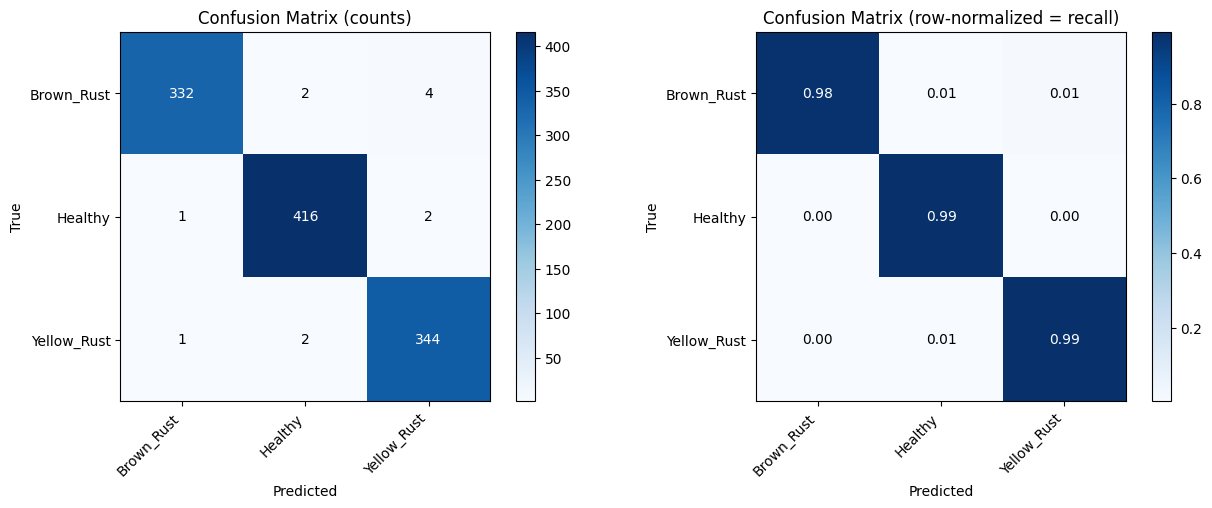


rust <-> rust    misclassifications: 5
rust <-> healthy misclassifications: 7
VERDICT: NOT consistent -- rust is confused with healthy more often than with the other rust.


In [26]:
from sklearn.metrics import (classification_report, confusion_matrix,
                             precision_recall_fscore_support)

def _eval(path):
    m = tf.keras.models.load_model(path)
    val_gen.reset()
    loss, acc = m.evaluate(val_gen, verbose=0)
    return m, acc, loss


m_final, acc_final, loss_final = _eval(FINAL_MODEL_PATH)
m_best,  acc_best,  loss_best  = _eval(MODEL_PATH)

print(f"{'Model':28s}{'val acc':>10s}{'val loss':>11s}")
print('-' * 49)
print(f"{'final epoch':28s}{acc_final:10.4f}{loss_final:11.4f}")
print(f"{'best checkpoint':28s}{acc_best:10.4f}{loss_best:11.4f}")
print('-' * 49)


model   = m_final
val_acc = acc_final
print(f"\nHeadline: final-epoch model, val accuracy {val_acc:.4f}\n")

val_gen.reset()
y_prob = model.predict(val_gen)
y_pred = np.argmax(y_prob, axis=1)
y_true = val_gen.classes          
assert len(y_pred) == len(y_true), f"length mismatch: {len(y_pred)} vs {len(y_true)}"

print(classification_report(y_true, y_pred, target_names=CLASS_NAMES,
                            digits=3, zero_division=0))


P, R, F, _ = precision_recall_fscore_support(
    y_true, y_pred, labels=range(NUM_CLASSES), zero_division=0)
PAPER_T3 = {'Yellow_Rust': (0.965, 0.948, 0.956),
            'Brown_Rust':  (0.961, 0.961, 0.961),
            'Healthy':     (0.960, 0.974, 0.966)}


cm = confusion_matrix(y_true, y_pred)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, (mat, title, fmt) in zip(axes, [
        (cm, 'Confusion Matrix (counts)', 'd'),
        (cm.astype(float) / cm.sum(axis=1, keepdims=True),
         'Confusion Matrix (row-normalized = recall)', '.2f')]):
    im = ax.imshow(mat, cmap='Blues')
    ax.set_title(title)
    ax.set_xticks(range(NUM_CLASSES)); ax.set_xticklabels(CLASS_NAMES, rotation=45, ha='right')
    ax.set_yticks(range(NUM_CLASSES)); ax.set_yticklabels(CLASS_NAMES)
    thr = mat.max() / 2
    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            ax.text(j, i, format(mat[i, j], fmt), ha='center', va='center',
                    color='white' if mat[i, j] > thr else 'black')
    ax.set_ylabel('True'); ax.set_xlabel('Predicted')
    fig.colorbar(im, ax=ax)
plt.tight_layout(); plt.show()

bi, hi, yi = (CLASS_NAMES.index(c) for c in ('Brown_Rust', 'Healthy', 'Yellow_Rust'))
rust_rust    = cm[bi, yi] + cm[yi, bi]
rust_healthy = cm[bi, hi] + cm[yi, hi] + cm[hi, bi] + cm[hi, yi]
print(f"\nrust <-> rust    misclassifications: {rust_rust}")
print(f"rust <-> healthy misclassifications: {rust_healthy}")

if rust_rust + rust_healthy == 0:
    print("VERDICT: no misclassifications at all -- nothing to compare.")
elif rust_rust > rust_healthy:
    print("VERDICT: consistent with the paper (errors are mostly rust<->rust).")
elif rust_rust == rust_healthy:
    print("VERDICT: inconclusive -- the two error types are equally common.")
else:
    print("VERDICT: NOT consistent -- rust is confused with healthy more often "
          "than with the other rust.")


In [20]:

for _p, _label in ((MODEL_PATH, 'best checkpoint'),
                   (FINAL_MODEL_PATH, 'final epoch (paper protocol)')):
    _m = tf.keras.models.load_model(_p)
    print(f"{_label:32s} {_p:42s} {_m.count_params():>10,} params")


import shutil as _sh
_sh.copy2(FINAL_MODEL_PATH, MODEL_PATH)
print(f"\nPromoted the final-epoch model to {MODEL_PATH} for app.py")


best checkpoint                  wheat_disease_cnn.keras                     2,175,683 params
final epoch (paper protocol)     wheat_disease_cnn_final_epoch.keras         2,175,683 params

Promoted the final-epoch model to wheat_disease_cnn.keras for app.py


In [21]:
#Single-image inference helper

In [22]:
from tensorflow.keras.preprocessing import image as keras_image

def predict_image(img_path_or_pil, model=model):
    """Classify a single wheat-leaf image. Accepts a file path or a PIL.Image.
    Returns (predicted_class, confidence, full_probability_dict)."""
    if isinstance(img_path_or_pil, str):
        img = keras_image.load_img(img_path_or_pil, target_size=IMG_SIZE)
    else:
        img = img_path_or_pil.convert('RGB').resize(IMG_SIZE)

    arr = keras_image.img_to_array(img) / 255.0
    arr = np.expand_dims(arr, axis=0)

    probs = model.predict(arr, verbose=0)[0]
    idx = int(np.argmax(probs))
    prob_dict = {CLASS_NAMES[i]: float(probs[i]) for i in range(NUM_CLASSES)}
    return CLASS_NAMES[idx], float(probs[idx]), prob_dict

sample_dir = os.path.join(VAL_DIR, CLASS_NAMES[0])
sample_file = os.path.join(sample_dir, os.listdir(sample_dir)[0])
pred, conf, allp = predict_image(sample_file)
print(f"File: {sample_file}")
print(f"Predicted: {pred}  (confidence {conf:.2%})")
print("All probabilities:", {k: round(v, 3) for k, v in allp.items()})

File: /kaggle/working/data_70_30/val/Brown_Rust/Brown_rust966.jpg
Predicted: Brown_Rust  (confidence 100.00%)
All probabilities: {'Brown_Rust': 1.0, 'Healthy': 0.0, 'Yellow_Rust': 0.0}


In [23]:
# Rule-Based Recommendation Module

In [24]:

RECOMMENDATION_DB = {
    'Yellow_Rust': {
        'common_names': ['yellow rust', 'stripe rust', 'yellow stripe', 'yr'],
        'symptoms': ['yellow stripes', 'yellow pustules', 'parallel stripes', 'yellowing leaves'],
        'recommendation': (
            'Apply a triazole fungicide (propiconazole or tebuconazole) at first sign. '
            'Use resistant varieties, avoid excessive nitrogen, and remove volunteer '
            'plants that harbor the pathogen. Monitor during cool, moist weather.'),
    },
    'Brown_Rust': {
        'common_names': ['brown rust', 'leaf rust', 'orange rust', 'br'],
        'symptoms': ['brown pustules', 'orange spots', 'round brown spots', 'reddish-brown spots'],
        'recommendation': (
            'Spray a strobilurin or triazole fungicide (azoxystrobin, tebuconazole) '
            'when pustules appear. Plant rust-resistant cultivars, keep fertilization '
            'balanced, and rotate crops to break the disease cycle.'),
    },
    'Powdery_Mildew': {
        'common_names': ['powdery mildew', 'pm', 'mildew'],
        'symptoms': ['white powdery growth', 'white patches', 'grey-white fungal growth',
                     'powdery coating'],
        'recommendation': (
            'Apply a triazole or strobilurin fungicide at early infection. Avoid dense '
            'canopies and excess nitrogen, widen row spacing for airflow, and grow '
            'resistant cultivars.'),
    },
    'Septoria_Leaf_Blotch': {
        'common_names': ['septoria leaf blotch', 'septoria', 'slb', 'leaf blotch'],
        'symptoms': ['irregular brown lesions', 'black pycnidia', 'oval tan lesions',
                     'leaf blotches'],
        'recommendation': (
            'Apply an azole fungicide (prothioconazole) at flag-leaf emergence. Use '
            'resistant varieties, rotate away from wheat, bury infected residue, and '
            'avoid very early sowing.'),
    },
    'Tan_Spot': {
        'common_names': ['tan spot', 'ts', 'yellow leaf spot', 'red smudge'],
        'symptoms': ['tan lesions with yellow halo', 'lens-shaped lesions', 'dark brown centre',
                     'tan spots'],
        'recommendation': (
            'Rotate away from wheat for at least one season and bury or remove stubble, '
            'which carries the pathogen. Apply a fungicide at flag leaf if lesions reach '
            'the upper canopy, and choose tolerant cultivars.'),
    },
    'Head_Blight': {
        'common_names': ['head blight', 'fusarium head blight', 'scab', 'hb', 'ear blight'],
        'symptoms': ['bleached spikelets', 'pink spore masses', 'shrivelled kernels',
                     'premature whitening of heads'],
        'recommendation': (
            'Spray prothioconazole or tebuconazole at early anthesis (flowering). Avoid '
            'planting into maize stubble, rotate with non-cereals, and use moderately '
            'resistant varieties. Test grain for deoxynivalenol (DON) mycotoxin before use.'),
    },
    'Loose_Smut': {
        'common_names': ['loose smut', 'ls', 'smut'],
        'symptoms': ['black powdery spore mass', 'heads replaced by spores',
                     'destroyed heads', 'black dusty heads'],
        'recommendation': (
            'Systemic seed treatment is the only effective control: treat with carboxin '
            'or tebuconazole before sowing. Always plant certified disease-free seed; '
            'foliar sprays cannot cure a seed-borne infection.'),
    },
    'Karnal_Bunt': {
        'common_names': ['karnal bunt', 'kb', 'partial bunt'],
        'symptoms': ['blackened kernels', 'fishy odour', 'partially bunted grain',
                     'black powder in grain'],
        'recommendation': (
            'Sow certified seed treated with a systemic fungicide, and apply propiconazole '
            'at heading in high-risk seasons. Observe quarantine rules for movement of '
            'grain, and avoid irrigation during flowering in humid conditions.'),
    },
    'Root_Rot': {
        'common_names': ['root rot', 'rr', 'common root rot', 'crown rot'],
        'symptoms': ['brown roots', 'darkened crown', 'stunted growth', 'poor tillering',
                     'whiteheads'],
        'recommendation': (
            'Use a fungicidal seed treatment, rotate with non-host crops, and improve '
            'drainage to avoid waterlogging. Maintain balanced nutrition and avoid deep '
            'sowing, which prolongs seedling vulnerability.'),
    },
    'Leaf_Blight': {
        'common_names': ['leaf blight', 'lb', 'helminthosporium leaf blight',
                        'spot blotch'],
        'symptoms': ['brown oval lesions', 'blighted leaves', 'dark brown spots',
                     'drying leaf tips'],
        'recommendation': (
            'Apply mancozeb or propiconazole at first appearance. Rotate crops, destroy '
            'infected residue, use clean seed, and grow tolerant varieties; the disease '
            'is worst under warm, humid conditions.'),
    },
    'BYDV': {
        'common_names': ['bydv', 'barley yellow dwarf virus', 'barley yellow dwarf',
                        'yellow dwarf'],
        'symptoms': ['yellow leaf tips', 'red-purple leaf discolouration', 'stunting',
                     'reduced tillering'],
        'recommendation': (
            'No cure once plants are infected -- control the aphid vector. Use insecticidal '
            'seed treatment, monitor and spray aphids in autumn, delay sowing to miss peak '
            'aphid flights, and grow tolerant varieties.'),
    },
    'WSBMV': {
        'common_names': ['wsbmv', 'wheat soilborne mosaic virus', 'soilborne mosaic',
                        'soil-borne mosaic'],
        'symptoms': ['mosaic mottling', 'yellow-green mottling', 'stunting',
                     'rosetting in patches'],
        'recommendation': (
            'Resistant varieties are the only practical control -- the virus is spread by '
            'the soil fungus Polymyxa graminis and cannot be treated chemically. Avoid '
            'very early sowing and steer clear of poorly drained fields with a history '
            'of the disease.'),
    },
    'WSMV': {
        'common_names': ['wsmv', 'wheat streak mosaic virus', 'wheat streak mosaic',
                        'streak mosaic'],
        'symptoms': ['yellow streaking', 'parallel yellow streaks', 'mosaic pattern',
                     'stunting'],
        'recommendation': (
            'Destroy volunteer wheat at least two weeks before sowing to break the '
            '"green bridge" that carries the wheat curl mite vector. Delay planting, '
            'control grassy weeds, and use resistant varieties. No chemical cure exists '
            'once plants are infected.'),
    },
    'Healthy': {
        'common_names': ['healthy', 'no disease', 'normal'],
        'symptoms': ['green leaves', 'no spots', 'healthy leaf'],
        'recommendation': (
            'No disease detected. Maintain good agronomic practices: balanced irrigation '
            'and fertilization, regular field scouting, and preventive monitoring during '
            'humid periods.'),
    },
}

def build_term_index(db):
    index = {}
    for disease, info in db.items():
        for term in info['common_names'] + info['symptoms']:
            index[term.lower()] = disease
    # Longest phrases first so multi-word terms match before single words
    return dict(sorted(index.items(), key=lambda kv: -len(kv[0])))

TERM_INDEX = build_term_index(RECOMMENDATION_DB)


DB_JSON_PATH = 'recommendation_db.json'
with open(DB_JSON_PATH, 'w') as f:
    json.dump(RECOMMENDATION_DB, f, indent=2)

_n_disease = len([k for k in RECOMMENDATION_DB if k != 'Healthy'])
print(f"{len(RECOMMENDATION_DB)} entries ({_n_disease} diseases + Healthy), "
      f"{len(TERM_INDEX)} searchable terms.")
print(f"Written to {DB_JSON_PATH} for app.py.")


print('Diseases:', ', '.join(k for k in RECOMMENDATION_DB if k != 'Healthy'))


14 entries (13 diseases + Healthy), 107 searchable terms.
Written to recommendation_db.json for app.py.
Diseases: Yellow_Rust, Brown_Rust, Powdery_Mildew, Septoria_Leaf_Blotch, Tan_Spot, Head_Blight, Loose_Smut, Karnal_Bunt, Root_Rot, Leaf_Blight, BYDV, WSBMV, WSMV


In [25]:
def extract_terms(text):
    """Extraction step: use regex to find known disease names / symptoms in user text."""
    text_l = text.lower()
    matched = []
    for term, disease in TERM_INDEX.items():
        
        pattern = r'\b' + re.escape(term) + r'\b'
        if re.search(pattern, text_l):
            matched.append((term, disease))
    return matched

def recommend_from_text(text):
    """Full pipeline: Extraction -> Alignment -> recommendation."""
    matches = extract_terms(text)
    if not matches:
        return {
            'query': text,
            'matched_terms': [],
            'diseases': [],
            'recommendations': [],
            'message': 'No known disease or symptom recognized. Please rephrase or upload an image.',
        }

    
    diseases = list(dict.fromkeys(d for _, d in matches))
    return {
        'query': text,
        'matched_terms': [t for t, _ in matches],
        'diseases': diseases,
        'recommendations': [
            {'disease': d, 'recommendation': RECOMMENDATION_DB[d]['recommendation']}
            for d in diseases
        ],
        'message': 'ok',
    }


for q in [
    "My wheat leaves have yellow stripes running along them",
    "I see round brown spots and orange pustules on the crop",
    "How do I treat yellow rust?",
    "The leaves look green and healthy",
    "there is something wrong but I am not sure",
]:
    r = recommend_from_text(q)
    print(f"Q: {q}")
    print(f"   matched: {r['matched_terms']} -> diseases: {r['diseases']}")
    for rec in r['recommendations']:
        print(f"   [{rec['disease']}] {rec['recommendation'][:80]}...")
    print()

Q: My wheat leaves have yellow stripes running along them
   matched: ['yellow stripes'] -> diseases: ['Yellow_Rust']
   [Yellow_Rust] Apply a triazole fungicide (propiconazole or tebuconazole) at first sign. Use re...

Q: I see round brown spots and orange pustules on the crop
   matched: ['round brown spots'] -> diseases: ['Brown_Rust']
   [Brown_Rust] Spray a strobilurin or triazole fungicide (azoxystrobin, tebuconazole) when pust...

Q: How do I treat yellow rust?
   matched: ['yellow rust'] -> diseases: ['Yellow_Rust']
   [Yellow_Rust] Apply a triazole fungicide (propiconazole or tebuconazole) at first sign. Use re...

Q: The leaves look green and healthy
   matched: ['healthy'] -> diseases: ['Healthy']
   [Healthy] No disease detected. Maintain good agronomic practices: balanced irrigation and ...

Q: there is something wrong but I am not sure
   matched: [] -> diseases: []

